In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from typing import Optional, List, Dict, Any  # Import typing module with commonly used types
#import pathlib
#import sys

#proj_src = pathlib.Path().resolve().parent.parent / "motec-ld-export-ui" / "motec-to-csv" / "src"
#sys.path.append(str(proj_src))
#from motec_converter import parse_race_data, to_pandas
#sys.path.remove(str(proj_src))

In [2]:
import sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [115]:
def _best_segment(motec_in_range: pd.DataFrame, dyno_duration_s: float,
                  gap_threshold_s: float = 2.0) -> pd.DataFrame:
    """
    Split motec_in_range into continuous segments (gaps > gap_threshold_s)
    and return the one whose duration is closest to dyno_duration_s.
    This prevents data from other speed ramps contaminating the match.
    """
    df = motec_in_range.copy().reset_index(drop=True)
    seg_id = (df["Time"].diff() > gap_threshold_s).cumsum()
    df["_seg"] = seg_id
 
    best_seg, best_delta = None, np.inf
    for seg, grp in df.groupby("_seg"):
        dur = grp["Time"].max() - grp["Time"].min()
        delta = abs(dur - dyno_duration_s)
        if delta < best_delta:
            best_delta, best_seg = delta, seg
 
    return df[df["_seg"] == best_seg].drop(columns="_seg")
 




def process_and_compute_efficiency(dyno_files, motec_files, target_torque=150,
                                   rpm_diff_tol=5, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    MOTEC_RPM = "Car.Data.Motor.MotorRPM"
    all_runs = []
    i= 0
    for motec_file, dyno_file in zip(motec_files, dyno_files):
        print(i)
        i+=1
        # --- Load dyno ---
        #print(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = pd.read_csv(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = cur_dyno_df.dropna(subset=['Axle Speed (rpm)', 'Axle Torque (Nm)'])

        cur_dyno_df['Calculated Motor RPM'] = cur_dyno_df['Axle Speed (rpm)'] * 38/11
        cur_dyno_df['Calculated Motor Torque'] = cur_dyno_df['Axle Torque (Nm)'] * 11/38
        
        
        rpm_min = cur_dyno_df["Calculated Motor RPM"].min()
        rpm_max = cur_dyno_df["Calculated Motor RPM"].max()
        dyno_dur  = cur_dyno_df["Time (sec)"].max() - cur_dyno_df["Time (sec)"].min()
        
        # --- Load MoTeC ---
        #motec_df = motec_files
        motec_df = pd.read_csv(f'Motec_Data/CSV Export/{motec_file}', header=8, low_memory=False)
        motec_df= motec_df.iloc[1:].reset_index(drop=True)
        motec_df = motec_df.apply(pd.to_numeric, errors='coerce')
        voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
        current_col = 'Car.Data.Inverter.InverterDCCurrent'
        motec_df['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))
        
        if not (motec_df[current_col] > 0).any():
            print("WARNING: No positive DC current detected. Skipping.")
            continue

            

        #print(rpm_min, rpm_max)
        
        # Filter by RPM range and target torque
        motec_in_range = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] >= target_torque) &
            (motec_df['Battery Power (kW)'] > 1)
            ].copy()

        
        motec_seg = _best_segment(motec_in_range, dyno_dur)
        print(f"  Best MoTeC segment: {len(motec_seg)} rows, \n"
              f" Time start: {motec_seg['Time'].max()}, Time end: {motec_seg['Time'].min()}\n"
              f"duration {motec_seg['Time'].max()-motec_seg['Time'].min():.1f} s, "
              f"RPM {motec_seg[MOTEC_RPM].min():.0f}–{motec_seg[MOTEC_RPM].max():.0f}")
 
        # ── Keep only the monotonically-increasing RPM portion ───────────────
        motec_mono = motec_seg[motec_seg[MOTEC_RPM].diff() > 0]
        motec_mono = motec_mono.rolling(rolling_window).mean().dropna()
        print(f"  After monotonic + rolling mean: {len(motec_mono)} rows")
 
        if motec_mono.empty:
            print("  No monotonic data — skipping.")
            continue
 
        # ── Nearest-neighbour match on RPM only ──────────────────────────────
        # InverterCalculatedTorque saturates at a command limit (not real output
        # torque) so it cannot be used as a matching feature.
        dyno_rpm   = cur_dyno_df["Calculated Motor RPM"].to_numpy().reshape(-1, 1)
        motec_rpm  = motec_mono[MOTEC_RPM].to_numpy().reshape(-1, 1)
 
        scaler = StandardScaler()
        dyno_scaled  = scaler.fit_transform(dyno_rpm)
        motec_scaled = scaler.transform(motec_rpm)
 
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_scaled)
        _, indices = nn.kneighbors(motec_scaled)
 
        matched_dyno  = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_mono.reset_index(drop=True)
 
        # RPM proximity filter
        rpm_diff = np.abs(
            matched_dyno["Calculated Motor RPM"].values
            - matched_motec[MOTEC_RPM].values
        )
        keep = (rpm_diff <= rpm_diff_tol)
        matched_dyno  = matched_dyno[keep].reset_index(drop=True)
        matched_motec = matched_motec[keep].reset_index(drop=True)
        print(f"  After RPM tolerance (±{rpm_diff_tol:.0f}): {len(matched_motec)} rows")
 
        if matched_motec.empty:
            print("  Skipping — no rows pass RPM tolerance.")
            continue
 
        # ── Efficiency ───────────────────────────────────────────────────────
        result = matched_motec.copy()
        result["Motor RPM (dyno)"]    = matched_dyno["Calculated Motor RPM"].values
        result["Motor Torque (dyno)"] = matched_dyno["Calculated Motor Torque"].values
        result["P_out_kW"] = (
            result["Motor Torque (dyno)"] * 2 * np.pi
            * result["Motor RPM (dyno)"] / 60 / 1000
        )
        result["P_in_kW"] = matched_motec["Battery Power (kW)"].values
        result["eff"]     = result["P_out_kW"] / result["P_in_kW"]
 
        print(f"  P_out {result['P_out_kW'].min():.1f}–{result['P_out_kW'].max():.1f} kW  "
              f"P_in {result['P_in_kW'].min():.1f}–{result['P_in_kW'].max():.1f} kW  "
              f"eff {result['eff'].min():.3f}–{result['eff'].max():.3f}")
        result["run"] =i
 
        all_runs.append(result)
 
    if not all_runs:
        print("\nNo runs produced data.")
        return pd.DataFrame()
 
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[(combined_df["eff"] > 0) & (combined_df["eff"] < 1)]
 
    print(f"\n{'='*60}")
    print(f"Total valid efficiency points : {len(combined_df)}")
    print(f"Mean efficiency               : {combined_df['eff'].mean():.3f}")
    print(f"Efficiency range              : {combined_df['eff'].min():.3f} – "
          f"{combined_df['eff'].max():.3f}")
 
    # ── Plots ────────────────────────────────────────────────────────────────
    if plot and not combined_df.empty:
        # 2-D scatter plot (RPM vs Efficiency)
        plt.figure(figsize=(12, 8))
        
        plt.scatter(
            combined_df["Motor RPM (dyno)"],
            combined_df["eff"],
            s=10,
            alpha=0.7
        )
        
        plt.xlabel("Motor RPM")
        plt.ylabel("Efficiency")
        plt.title("Efficiency vs Motor RPM")
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
 
    return combined_df


In [116]:
def plot_interactive_efficiency(combined_df):
    fig = px.scatter_3d(
        combined_df, 
        x='Car.Data.Motor.MotorRPM', 
        y='Car.Data.Inverter.InverterCalculatedTorque', 
        z='eff',
        color='run',
        color_continuous_scale='RdYlGn',
        title="Interactive Motor Efficiency Map",
        labels={'eff': 'Efficiency', 'Car.Data.Motor.MotorRPM': 'RPM', 'Car.Data.Inverter.InverterCalculatedTorque': 'Torque (Nm)'}
    )
    
    fig.update_traces(marker=dict(size=3))
    fig.show()

In [117]:
from pathlib import Path


folder = Path("Dyno_Data")

csv_files = [f.name for f in folder.glob('*.csv')]

print(csv_files)

import re
def extract_run_number(filename):
    return int(re.search(r"speedramp(\d+)", filename).group(1))

# filter out 13, then sort
sorted_dyno_files = sorted(
    [f for f in csv_files if extract_run_number(f) <= 12],
    key=extract_run_number
)


['speedramp10_pl140_manual_dhruv.csv', 'speedramp11_pl150_manual_dhruv.csv', 'speedramp12_pl160_maual_dhruv_failed.csv', 'speedramp13_pl167-1_manual_dhruv_failed.csv', 'speedramp1_pl50_manual_dhruv.csv', 'speedramp2_pl60_manual_dhruv.csv', 'speedramp3_pl70_manual_dhruv.csv', 'speedramp4_pl80_manual_dhruv.csv', 'speedramp5_pl90_manual_dhruv.csv', 'speedramp6_pl100_manual_dhruv.csv', 'speedramp7_pl110_manual_dhruv.csv', 'speedramp8_pl120_manual_dhruv.csv', 'speedramp9_pl130_manual_dhruv.csv']


In [118]:
folder = Path("Motec_Data/CSV Export")

csv_motec_files = [f.name for f in folder.glob('*.csv')]

def extract_num(f):
    return int(re.search(r"_(\d+)\.csv", f).group(1))

# filter + sort
motec_sorted = sorted(
    [f for f in csv_motec_files if "dyno_arvo" in f],
    key=extract_num
)

print(motec_sorted)

['dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv']


In [119]:
dyno_matched = ['speedramp4_pl80_manual_dhruv.csv','speedramp4_pl80_manual_dhruv.csv', 'speedramp3_pl70_manual_dhruv.csv', 'speedramp8_pl120_manual_dhruv.csv']
motec_matched = ['dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv','dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv','dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv','dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv']


# Maybe something wrong with motec file 7
# motec file 6 has higher torque of around 160+

0
  Best MoTeC segment: 1708 rows, 
 Time start: 1396.14, Time end: 1379.06
duration 17.1 s, RPM 1394–4877
  After monotonic + rolling mean: 874 rows
  After RPM tolerance (±5): 834 rows
  P_out 10.5–38.4 kW  P_in 15.5–53.5 kW  eff 0.661–0.741
1
  Best MoTeC segment: 1706 rows, 
 Time start: 1072.49, Time end: 1055.38
duration 17.1 s, RPM 1395–4876
  After monotonic + rolling mean: 891 rows
  After RPM tolerance (±5): 862 rows
  P_out 10.5–38.2 kW  P_in 15.4–53.7 kW  eff 0.657–0.734
2
  Best MoTeC segment: 1604 rows, 
 Time start: 622.49, Time end: 606.46
duration 16.0 s, RPM 1608–4886
  After monotonic + rolling mean: 870 rows
  After RPM tolerance (±5): 840 rows
  P_out 10.5–33.2 kW  P_in 9.7–29.8 kW  eff 1.024–1.141
3
  Best MoTeC segment: 2270 rows, 
 Time start: 2696.8, Time end: 2674.1
duration 22.7 s, RPM 1577–4797
  After monotonic + rolling mean: 1141 rows
  After RPM tolerance (±5): 1098 rows
  P_out 17.1–47.9 kW  P_in 2.8–9.5 kW  eff 4.496–6.297

Total valid efficiency point

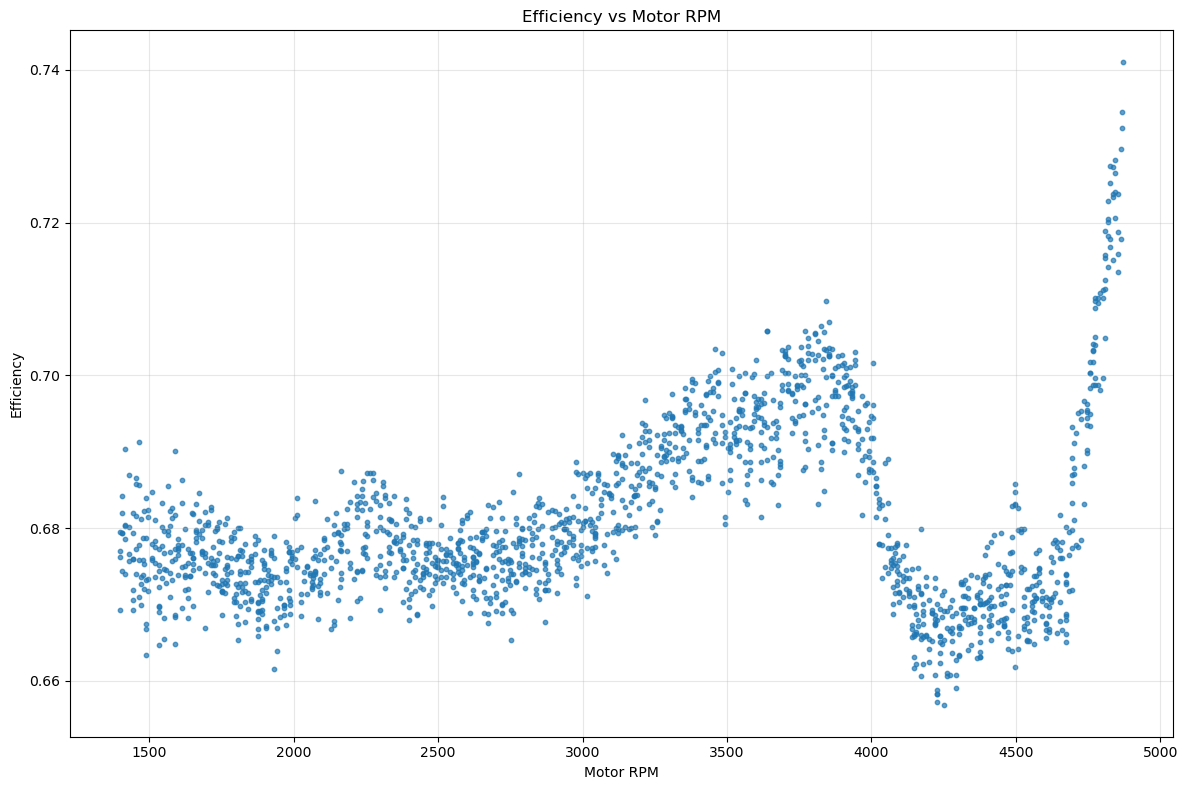

In [120]:
combined_df= process_and_compute_efficiency(dyno_matched, motec_matched, target_torque=0, rolling_window=3, plot=True)

In [103]:
plot_interactive_efficiency(combined_df)